In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

from scipy.interpolate import interp1d

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
wise = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/w1_bright-2mass-13.3-dr9.fits'))
print(len(wise))

wise['w1ab'] = np.array(wise['W1MPRO']) + 2.699

10063086


In [4]:
wise[:1]

RA,DEC,W1MPRO,w1ab
float64,float64,float64,float64
326.7289468,-69.7449369,8.413,11.112


In [5]:
print(wise['w1ab'].min(), wise['w1ab'].max())

-1.5280002365112306 15.998


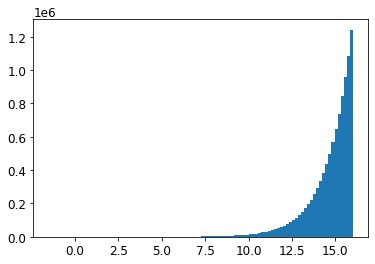

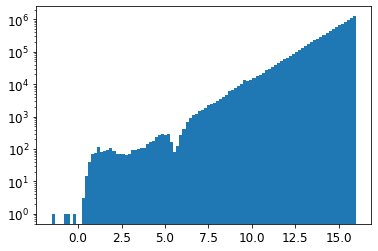

In [6]:
plt.hist(wise['w1ab'], 100)
plt.show()

plt.hist(wise['w1ab'], 100, log=True)
plt.show()

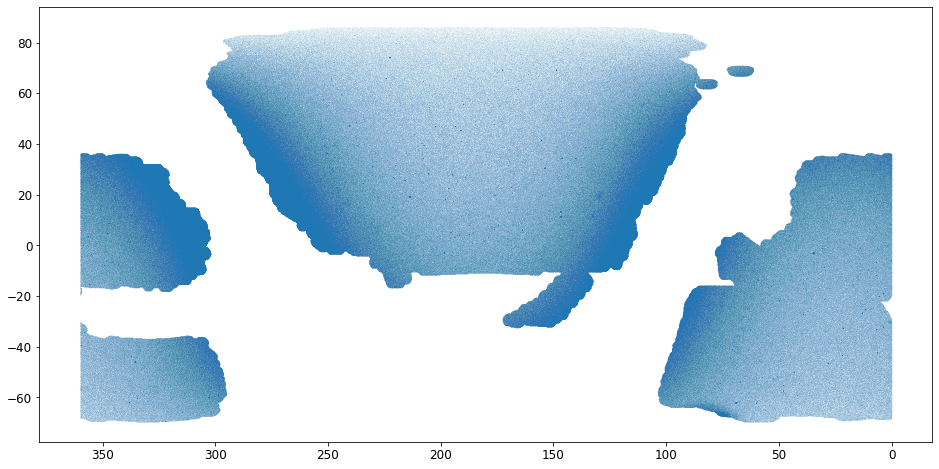

In [7]:
plt.figure(figsize=(16, 8))
plt.plot(wise['RA'], wise['DEC'], '.', ms=0.1, alpha=0.1)
plt.gca().invert_xaxis()
plt.show()

In [8]:
target_class = 'lrg'
cat_south = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_{}_south_1.0.0_basic.fits'.format(target_class), columns=['RA', 'DEC']))
cat_north = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_{}_north_1.0.0_basic.fits'.format(target_class), columns=['RA', 'DEC']))
cat = vstack([cat_south, cat_north])
print(len(cat))

12338990


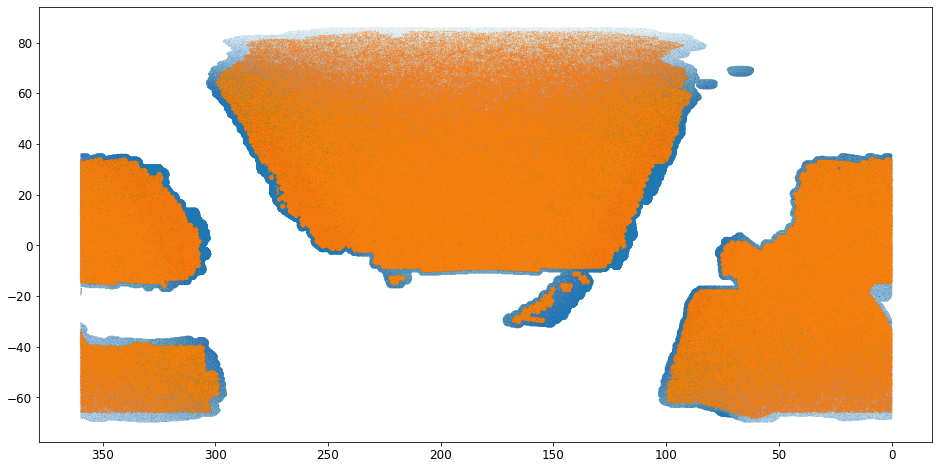

In [9]:
plt.figure(figsize=(16, 8))

plt.plot(wise['RA'], wise['DEC'], '.', ms=0.1, alpha=0.1)

idx = np.random.choice(len(cat), size=len(cat)//5)
plt.plot(cat['RA'][idx], cat['DEC'][idx], '.', ms=0.1, alpha=1)

plt.gca().invert_xaxis()
plt.show()

--------
# v1

In [50]:
mags = [0, 0.5, 1, 2, 2.5, 4.0, 5.0, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0]
radii = [600, 600, 500, 425, 375, 350, 350, 300, 250, 200, 175, 150, 100, 100]
max_mag = 9.0

f = interp1d(mags, radii, bounds_error=False, fill_value='extrapolate')

mask = wise['w1ab']<=max_mag
wise['radius'] = 0.
wise['radius'][mask] = f(wise['w1ab'][mask])

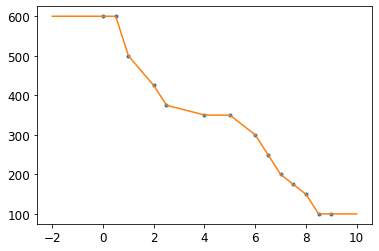

In [51]:
mags_plot = np.linspace(-2, 10, 1000)
plt.plot(mags, radii, '.')
plt.plot(mags_plot, f(mags_plot))
plt.show()

In [52]:
w1_max_list = np.arange(0, 11, 0.1)
masked_area = np.zeros(len(w1_max_list))
for index, w1_max in enumerate(w1_max_list):
    mask = wise['w1ab']<w1_max
    masked_area[index] = np.sum(np.pi*(wise['radius'][mask]/3600)**2)  # in sq. deg.

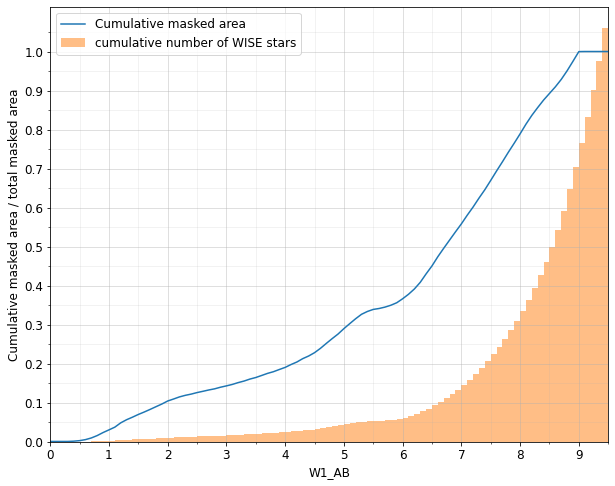

In [53]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(w1_max_list, masked_area/masked_area.max(), label='Cumulative masked area')
ax.set_xlabel('W1_AB')
ax.set_ylabel('Cumulative masked area / total masked area')
mask = wise['w1ab']<10.
ax.hist(wise['w1ab'], cumulative=True, range=(0, 9.5), bins=95, alpha=0.5, label='cumulative number of WISE stars',
        weights=np.full(len(wise),1.6/np.sum(mask)))
ax.legend()
ax.grid(alpha=0.5)

x_major_ticks = np.arange(0, 21, 1)
x_minor_ticks = np.arange(0, 21, 0.5)
y_major_ticks = np.arange(0, 1.1, 0.1)
y_minor_ticks = np.arange(0, 1.1, 0.05)

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)


ax.grid(which='both')
ax.grid(which='minor', alpha=0.2)
ax.grid(which='major', alpha=0.5)

plt.xlim(0, 9.5)

plt.show()

--------
# v1

In [54]:
mags = [0, 0.5, 1, 2, 2.5, 4.0, 5.0, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0]
radii = [600, 600, 500, 425, 375, 350, 350, 300, 250, 200, 175, 150, 100, 100]
max_mag = 9.0

f_v1 = interp1d(mags, radii, bounds_error=False, fill_value='extrapolate')

mask = wise['w1ab']<=max_mag
wise['radius'] = 0.
wise['radius'][mask] = f(wise['w1ab'][mask])

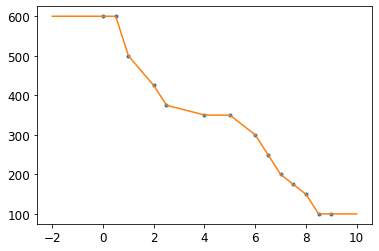

In [55]:
mags_plot = np.linspace(-2, 10, 1000)
plt.plot(mags, radii, '.')
plt.plot(mags_plot, f_v1(mags_plot))
plt.show()

In [56]:
w1_max_list = np.arange(0, 11, 0.1)
masked_area = np.zeros(len(w1_max_list))
for index, w1_max in enumerate(w1_max_list):
    mask = wise['w1ab']<w1_max
    masked_area[index] = np.sum(np.pi*(wise['radius'][mask]/3600)**2)  # in sq. deg.
    
print(masked_area.max())

384.5663728626613


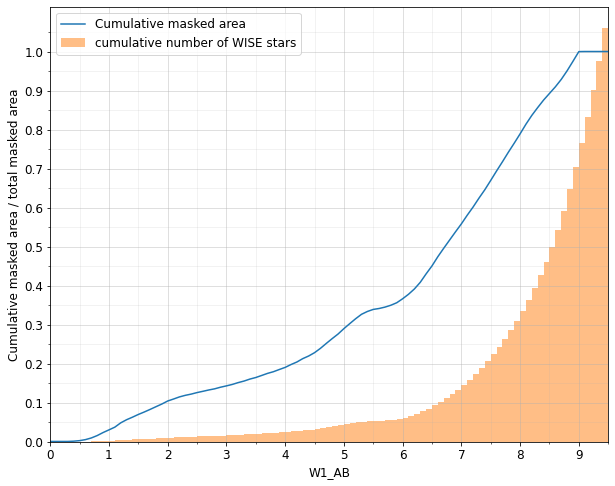

In [57]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(w1_max_list, masked_area/masked_area.max(), label='Cumulative masked area')
ax.set_xlabel('W1_AB')
ax.set_ylabel('Cumulative masked area / total masked area')
mask = wise['w1ab']<10.
ax.hist(wise['w1ab'], cumulative=True, range=(0, 9.5), bins=95, alpha=0.5, label='cumulative number of WISE stars',
        weights=np.full(len(wise),1.6/np.sum(mask)))
ax.legend()
ax.grid(alpha=0.5)

x_major_ticks = np.arange(0, 21, 1)
x_minor_ticks = np.arange(0, 21, 0.5)
y_major_ticks = np.arange(0, 1.1, 0.1)
y_minor_ticks = np.arange(0, 1.1, 0.05)

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)


ax.grid(which='both')
ax.grid(which='minor', alpha=0.2)
ax.grid(which='major', alpha=0.5)

plt.xlim(0, 9.5)

plt.show()

--------
# v2

In [58]:
mags = [0, 0.5, 1, 1.5, 2, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
radii = [600, 600, 550, 500, 475, 425, 400, 400, 375, 375, 375, 350, 325, 300, 250, 225, 175, 150, 75, 50, 50]
max_mag = 10.0
f_radius = interp1d(mags, radii, bounds_error=False, fill_value='extrapolate')

f_v2 = interp1d(mags, radii, bounds_error=False, fill_value='extrapolate')

mask = wise['w1ab']<=max_mag
wise['radius'] = 0.
wise['radius'][mask] = f_v2(wise['w1ab'][mask])

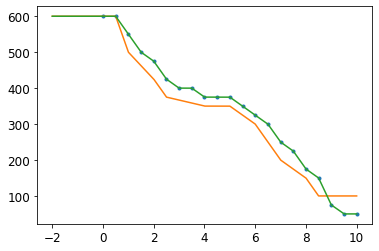

In [59]:
mags_plot = np.linspace(-2, 10, 1000)
plt.plot(mags, radii, '.')
plt.plot(mags_plot, f_v1(mags_plot))
plt.plot(mags_plot, f_v2(mags_plot))
plt.show()

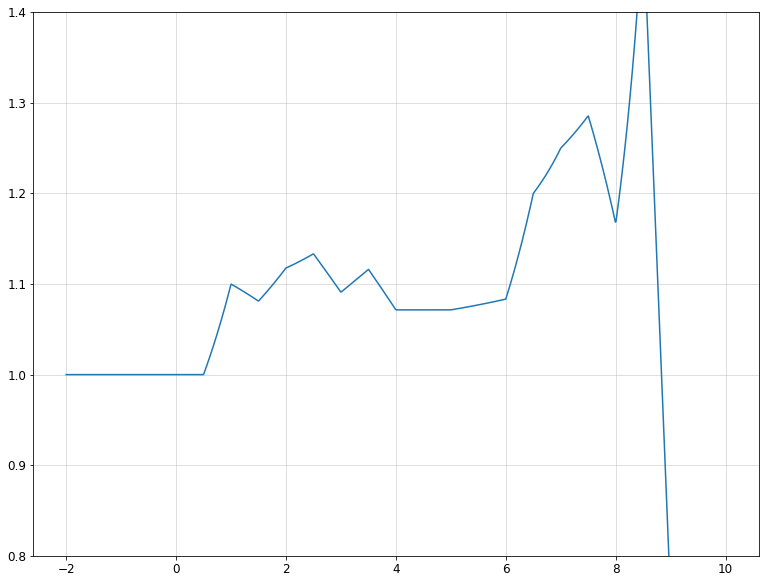

In [60]:
mags_plot = np.linspace(-2, 10, 1000)
plt.figure(figsize=(13, 10))
plt.plot(mags_plot, f_v2(mags_plot)/f_v1(mags_plot))
plt.grid(alpha=0.5)
plt.ylim(0.8, 1.4)
plt.show()

In [61]:
w1_max_list = np.arange(0, 11, 0.1)
masked_area = np.zeros(len(w1_max_list))
for index, w1_max in enumerate(w1_max_list):
    mask = wise['w1ab']<w1_max
    masked_area[index] = np.sum(np.pi*(wise['radius'][mask]/3600)**2)  # in sq. deg.
    
print(masked_area.max())

573.0886236967526


In [62]:
573.0886236967526/384.5663728626613

1.4902203212172624

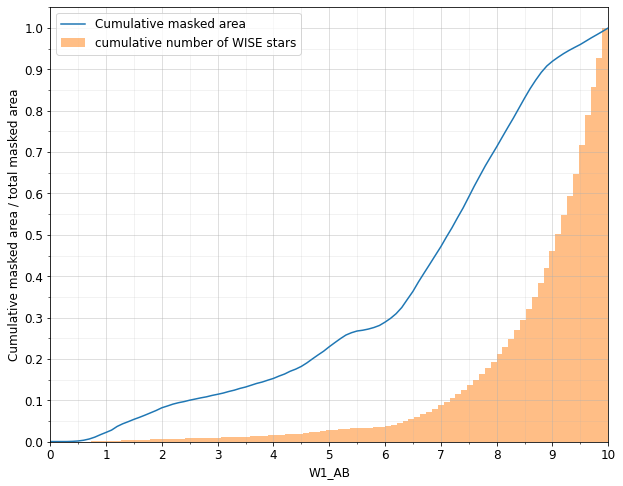

In [63]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(w1_max_list, masked_area/masked_area.max(), label='Cumulative masked area')
ax.set_xlabel('W1_AB')
ax.set_ylabel('Cumulative masked area / total masked area')
mask = wise['w1ab']<10.
ax.hist(wise['w1ab'], cumulative=True, range=(0, 10.), bins=95, alpha=0.5, label='cumulative number of WISE stars',
        weights=np.full(len(wise),1./np.sum(mask)))
ax.legend()
ax.grid(alpha=0.5)

x_major_ticks = np.arange(0, 21, 1)
x_minor_ticks = np.arange(0, 21, 0.5)
y_major_ticks = np.arange(0, 1.1, 0.1)
y_minor_ticks = np.arange(0, 1.1, 0.05)

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)


ax.grid(which='both')
ax.grid(which='minor', alpha=0.2)
ax.grid(which='major', alpha=0.5)

plt.xlim(0, 10.)

plt.show()

--------
# v3

In [74]:
mags = [0, 0.5, 1, 1.5, 2, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
radii = [600, 600, 550, 500, 475, 425, 400, 400, 390, 392.5, 395, 370, 360, 330, 275, 240, 210, 165, 100, 50, 50]
max_mag = 10.0
f_radius = interp1d(mags, radii, bounds_error=False, fill_value='extrapolate')

f_v3 = interp1d(mags, radii, bounds_error=False, fill_value='extrapolate')

mask = wise['w1ab']<=max_mag
wise['radius'] = 0.
wise['radius'][mask] = f_v3(wise['w1ab'][mask])

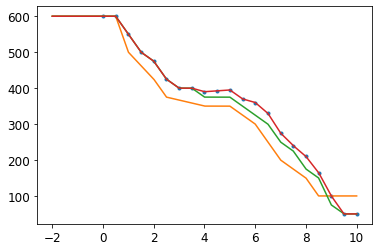

In [75]:
mags_plot = np.linspace(-2, 10, 1000)
plt.plot(mags, radii, '.')
plt.plot(mags_plot, f_v1(mags_plot))
plt.plot(mags_plot, f_v2(mags_plot))
plt.plot(mags_plot, f_v3(mags_plot))
plt.show()

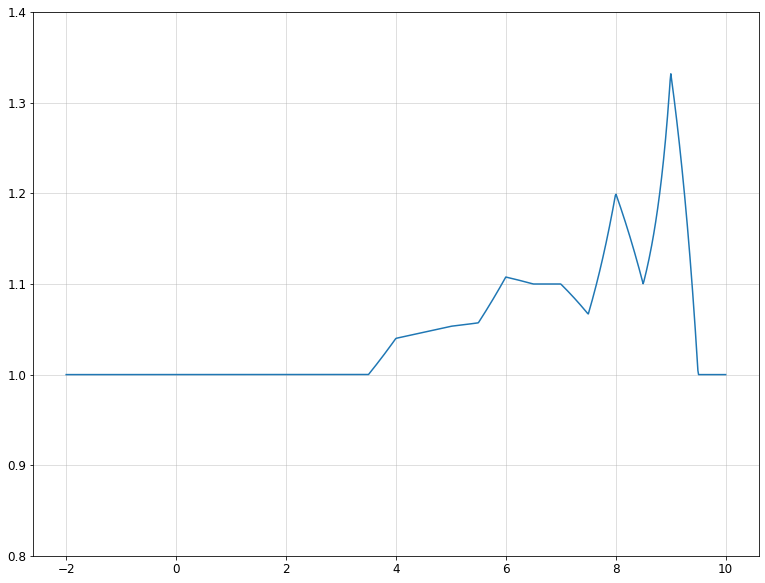

In [76]:
mags_plot = np.linspace(-2, 10, 1000)
plt.figure(figsize=(13, 10))
plt.plot(mags_plot, f_v3(mags_plot)/f_v2(mags_plot))
plt.grid(alpha=0.5)
plt.ylim(0.8, 1.4)
plt.show()

In [77]:
w1_max_list = np.arange(0, 11, 0.1)
masked_area = np.zeros(len(w1_max_list))
for index, w1_max in enumerate(w1_max_list):
    mask = wise['w1ab']<w1_max
    masked_area[index] = np.sum(np.pi*(wise['radius'][mask]/3600)**2)  # in sq. deg.
    
print(masked_area.max())

687.7068470153649


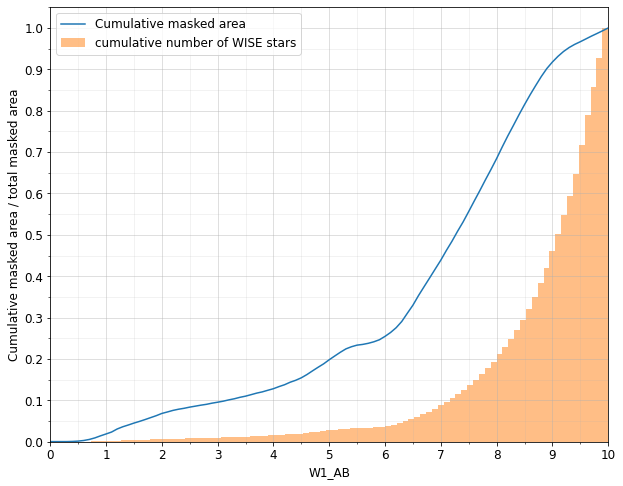

In [78]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(w1_max_list, masked_area/masked_area.max(), label='Cumulative masked area')
ax.set_xlabel('W1_AB')
ax.set_ylabel('Cumulative masked area / total masked area')
mask = wise['w1ab']<10.
ax.hist(wise['w1ab'], cumulative=True, range=(0, 10.), bins=95, alpha=0.5, label='cumulative number of WISE stars',
        weights=np.full(len(wise),1./np.sum(mask)))
ax.legend()
ax.grid(alpha=0.5)

x_major_ticks = np.arange(0, 21, 1)
x_minor_ticks = np.arange(0, 21, 0.5)
y_major_ticks = np.arange(0, 1.1, 0.1)
y_minor_ticks = np.arange(0, 1.1, 0.05)

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)


ax.grid(which='both')
ax.grid(which='minor', alpha=0.2)
ax.grid(which='major', alpha=0.5)

plt.xlim(0, 10.)

plt.show()

--------
# v4

In [64]:
mags = [0, 0.5, 1, 1.5, 2, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5]
radii = [600, 600, 550, 500, 475, 425, 400, 400, 390, 392.5, 395, 370, 360, 330, 275, 240, 210, 165, 100, 75, 60, 60]
max_mag = 10.0
f_radius = interp1d(mags, radii, bounds_error=False, fill_value='extrapolate')

f_v4 = interp1d(mags, radii, bounds_error=False, fill_value='extrapolate')

mask = wise['w1ab']<=max_mag
wise['radius'] = 0.
wise['radius'][mask] = f_v4(wise['w1ab'][mask])

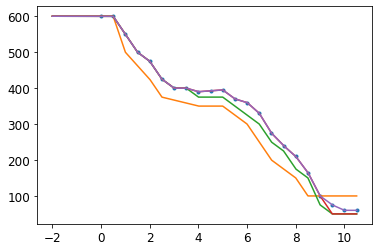

In [65]:
mags_plot = np.linspace(-2, 10.5, 1000)
plt.plot(mags, radii, '.')
plt.plot(mags_plot, f_v1(mags_plot))
plt.plot(mags_plot, f_v2(mags_plot))
plt.plot(mags_plot, f_v3(mags_plot))
plt.plot(mags_plot, f_v4(mags_plot))

plt.show()

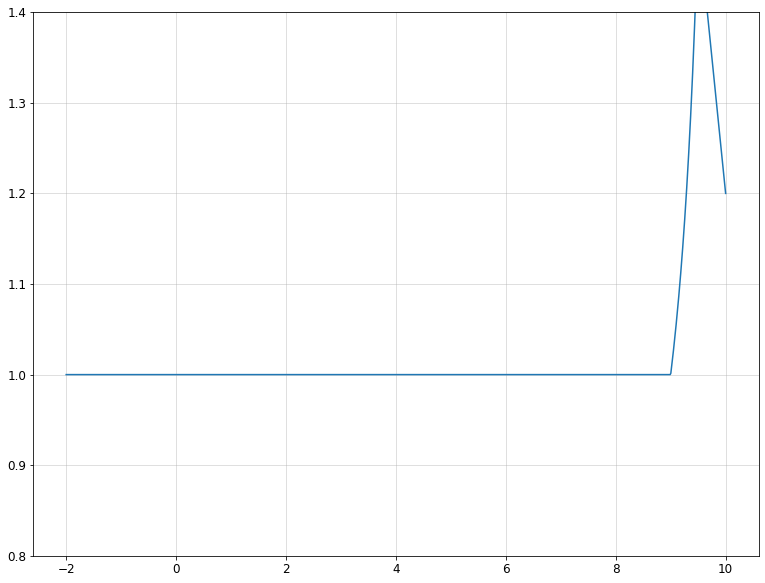

In [66]:
mags_plot = np.linspace(-2, 10, 1000)
plt.figure(figsize=(13, 10))
plt.plot(mags_plot, f_v4(mags_plot)/f_v3(mags_plot))
plt.grid(alpha=0.5)
plt.ylim(0.8, 1.4)
plt.show()

In [67]:
w1_max_list = np.arange(0, 11, 0.1)
masked_area = np.zeros(len(w1_max_list))
for index, w1_max in enumerate(w1_max_list):
    mask = wise['w1ab']<w1_max
    masked_area[index] = np.sum(np.pi*(wise['radius'][mask]/3600)**2)  # in sq. deg.
    
print(masked_area.max())

718.6276042670145


In [79]:
718.6276042670145/687.7068470153649

1.0449621192312466

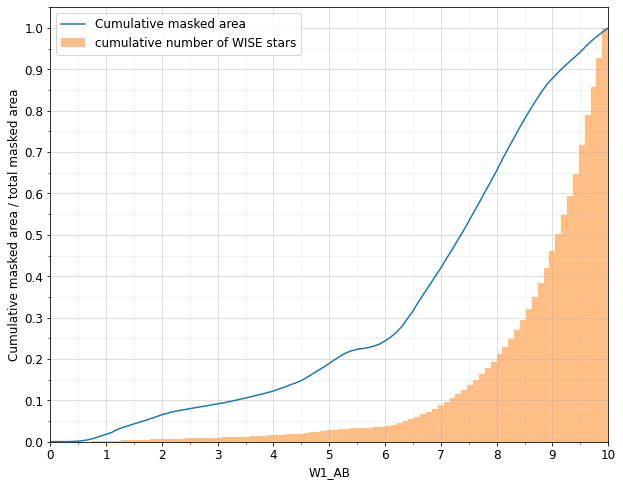

In [68]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(w1_max_list, masked_area/masked_area.max(), label='Cumulative masked area')
ax.set_xlabel('W1_AB')
ax.set_ylabel('Cumulative masked area / total masked area')
mask = wise['w1ab']<10.
ax.hist(wise['w1ab'], cumulative=True, range=(0, 10.), bins=95, alpha=0.5, label='cumulative number of WISE stars',
        weights=np.full(len(wise),1./np.sum(mask)))
ax.legend()
ax.grid(alpha=0.5)

x_major_ticks = np.arange(0, 21, 1)
x_minor_ticks = np.arange(0, 21, 0.5)
y_major_ticks = np.arange(0, 1.1, 0.1)
y_minor_ticks = np.arange(0, 1.1, 0.05)

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)


ax.grid(which='both')
ax.grid(which='minor', alpha=0.2)
ax.grid(which='major', alpha=0.5)

plt.xlim(0, 10.)

plt.show()